# Breast Cancer Logistic Regression

The logistic regression model performed very well on the breast cancer dataset, reaching an accuracy of 95.6% and an AUC of 0.9977, which means it can separate malignant and benign cases with a very high degree of confidence. The feature coefficients show that measurements capturing how irregular or large a tumor is play the biggest role in the prediction. Positive coefficients like *texture error* and *mean radius* were more associated with benign outcomes, while negative coefficients such as *worst concavity*, *worst compactness*, and *worst symmetry* were closely linked to malignancy. Looking at each feature on its own, the “worst” measurements—especially worst perimeter, worst area, and worst radius—stood out with AUC scores above 0.99, meaning they are extremely strong predictors by themselves. Overall, the results highlight that tumor size and shape irregularities, particularly at their most severe, carry the most explanatory power in distinguishing malignant from benign cases.


In [ ]:
from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, roc_auc_score
import pandas as pd
import numpy as np

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Base Logistic Regression model
model = LogisticRegression(max_iter=5000)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

# Overall metrics
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Model Accuracy: {acc:.4f}")
print(f"Model AUC: {auc:.4f}")

# FEATURE IMPORTANCE
importance = pd.Series(model.coef_[0], index=X.columns).sort_values(ascending=False)

print("\nTop Positive Predictors:")
print(importance.head(10))

print("\nTop Negative Predictors:")
print(importance.tail(10))

# EXPLANATORY POWER BY FEATURE
single_feature_auc = {}

for feature in X.columns:
    Xi = X[[feature]]
    Xi_train, Xi_test, yi_train, yi_test = train_test_split(
        Xi, y, test_size=0.2, random_state=42
    )

    m = LogisticRegression(max_iter=5000)
    m.fit(Xi_train, yi_train)

    yi_proba = m.predict_proba(Xi_test)[:, 1]
    single_feature_auc[feature] = roc_auc_score(yi_test, yi_proba)

# Sort by AUC
single_feature_auc = dict(
    sorted(single_feature_auc.items(), key=lambda x: x[1], reverse=True)
)

print("\nTop Individual Feature AUC Scores:")
for feat, val in list(single_feature_auc.items())[:10]:
    print(f"{feat}: {val:.4f}")


Model Accuracy: 0.9561
Model AUC: 0.9977

Top Positive Predictors:
texture error              1.370567
mean radius                1.027437
mean texture               0.221451
worst radius               0.111653
compactness error          0.047361
mean area                  0.025467
fractal dimension error    0.011605
worst perimeter           -0.015554
worst area                -0.016857
smoothness error          -0.022455
dtype: float64

Top Negative Predictors:
mean compactness       -0.237713
mean concave points    -0.283692
worst smoothness       -0.307731
mean perimeter         -0.362135
worst texture          -0.508877
worst concave points   -0.510929
mean concavity         -0.532558
worst symmetry         -0.746894
worst compactness      -0.772709
worst concavity        -1.428595
dtype: float64

Top Individual Feature AUC Scores:
worst perimeter: 0.9934
worst area: 0.9908
worst radius: 0.9907
worst concave points: 0.9784
mean perimeter: 0.9764
area error: 0.9718
mean area: 0.970

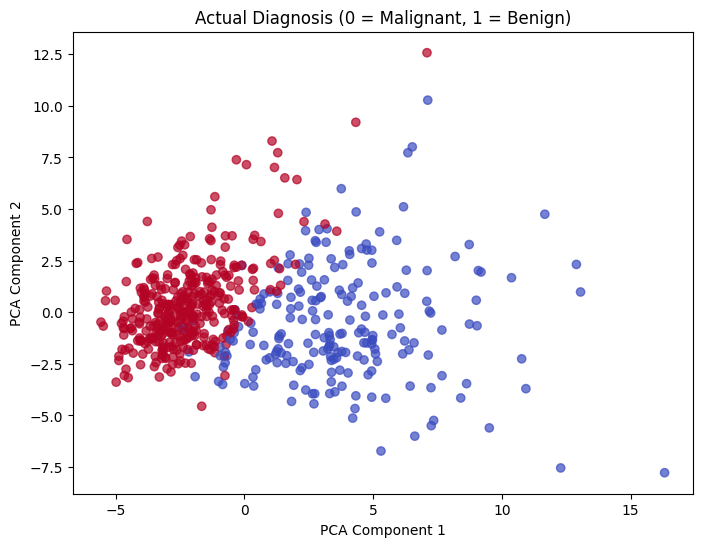

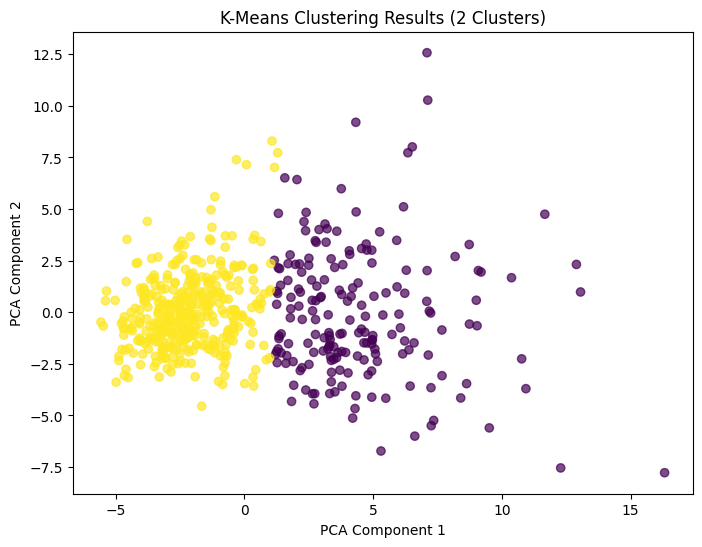

Cluster/Label Alignment: 0.9121


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans

# Load dataset
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  # 0 = malignant, 1 = benign

# Scale the data for clustering
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# PCA for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# K-Means clustering
kmeans = KMeans(n_clusters=2, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# ----- Plot 1: Actual Labels -----
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=y, cmap="coolwarm", alpha=0.7)
plt.title("Actual Diagnosis (0 = Malignant, 1 = Benign)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# ----- Plot 2: K-Means Clusters -----
plt.figure(figsize=(8,6))
plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap="viridis", alpha=0.7)
plt.title("K-Means Clustering Results (2 Clusters)")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.show()

# Optional: Cluster-label agreement
matches = sum(clusters == y) / len(y)
print(f"Cluster/Label Alignment: {matches:.4f}")
